**One-month training sensitivity experiment**

In addition to the main models trained with all available historical data, a one-month sensitivity experiment was conducted. This experiment uses only March 2026 data and applies a chronological train-validation-test split within this limited period. The purpose is to evaluate whether the LSTM model can still provide useful short-term forecasts when only a limited amount of recent data is available, which is relevant for a potential online deployment scenario.

**LSA16**

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ============================================================
# SETTINGS
# ============================================================

LSA_NAME = "LSA16"   # change to LSA10, LSA1, or LSA9
MONTH_START = "2026-03-01"
MONTH_END   = "2026-04-01"

LOOKBACK = 4
HORIZON = 1

BASE_DIR = Path(r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model")
APPROACH_CSV = BASE_DIR / LSA_NAME / f"{LSA_NAME}_approach_counts_15min.csv"

# ============================================================
# LOAD
# ============================================================

df = pd.read_csv(APPROACH_CSV)

df["timestamp_berlin"] = pd.to_datetime(df["timestamp_berlin"], utc=True, errors="coerce")
df["timestamp_berlin"] = df["timestamp_berlin"].dt.tz_convert("Europe/Berlin").dt.tz_localize(None)
df = df.sort_values("timestamp_berlin").reset_index(drop=True)

count_cols = [col for col in df.columns if col.endswith("_count")]

data = df[["timestamp_berlin"] + count_cols].copy()
data[count_cols] = data[count_cols].ffill().bfill()

# ============================================================
# FILTER ONE MONTH
# ============================================================

month_df = data[
    (data["timestamp_berlin"] >= MONTH_START) &
    (data["timestamp_berlin"] < MONTH_END)
].copy()

print("One-month data shape:", month_df.shape)
print("Time range:", month_df["timestamp_berlin"].min(), "to", month_df["timestamp_berlin"].max())
print("Features:", count_cols)

# ============================================================
# CHRONOLOGICAL SPLIT
# ============================================================

n = len(month_df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = month_df.iloc[:train_end].copy()
val_df   = month_df.iloc[train_end:val_end].copy()
test_df  = month_df.iloc[val_end:].copy()

print("\nSplit sizes:")
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nTime ranges:")
print("Train:", train_df["timestamp_berlin"].min(), "to", train_df["timestamp_berlin"].max())
print("Val:  ", val_df["timestamp_berlin"].min(), "to", val_df["timestamp_berlin"].max())
print("Test: ", test_df["timestamp_berlin"].min(), "to", test_df["timestamp_berlin"].max())

# ============================================================
# SCALING
# ============================================================

scaler = MinMaxScaler()
scaler.fit(train_df[count_cols])

train_scaled = scaler.transform(train_df[count_cols])
val_scaled   = scaler.transform(val_df[count_cols])
test_scaled  = scaler.transform(test_df[count_cols])

# ============================================================
# SEQUENCE GENERATION
# ============================================================

def create_sequences(array_2d, lookback=4, horizon=1):
    X, y = [], []
    for i in range(len(array_2d) - lookback - horizon + 1):
        X.append(array_2d[i:i+lookback])
        y.append(array_2d[i+lookback+horizon-1])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, LOOKBACK, HORIZON)
X_val, y_val     = create_sequences(val_scaled, LOOKBACK, HORIZON)
X_test, y_test   = create_sequences(test_scaled, LOOKBACK, HORIZON)

print("\nSequence shapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:  ", X_val.shape, "y_val:", y_val.shape)
print("X_test: ", X_test.shape, "y_test:", y_test.shape)

# ============================================================
# NAIVE BASELINE
# ============================================================

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

y_pred_naive_scaled = X_test[:, -1, :]

y_test_actual = scaler.inverse_transform(y_test)
y_pred_naive_actual = scaler.inverse_transform(y_pred_naive_scaled)

overall_mae_naive = mean_absolute_error(y_test_actual, y_pred_naive_actual)
overall_rmse_naive = rmse(y_test_actual, y_pred_naive_actual)

# ============================================================
# LSTM
# ============================================================

n_features = X_train.shape[2]

model = Sequential([
    Input(shape=(LOOKBACK, n_features)),
    LSTM(64),
    Dropout(0.2),
    Dense(n_features)
])

model.compile(optimizer="adam", loss="mse")

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# ============================================================
# EVALUATION
# ============================================================

y_pred_lstm_scaled = model.predict(X_test)
y_pred_lstm_actual = scaler.inverse_transform(y_pred_lstm_scaled)

overall_mae_lstm = mean_absolute_error(y_test_actual, y_pred_lstm_actual)
overall_rmse_lstm = rmse(y_test_actual, y_pred_lstm_actual)

print("\nOne-month experiment:", LSA_NAME)
print("Naive MAE :", round(overall_mae_naive, 3))
print("Naive RMSE:", round(overall_rmse_naive, 3))

print("\nLSTM MAE :", round(overall_mae_lstm, 3))
print("LSTM RMSE:", round(overall_rmse_lstm, 3))

print("\nImprovement:")
print("MAE improvement (%):", round((overall_mae_naive - overall_mae_lstm) / overall_mae_naive * 100, 2))
print("RMSE improvement (%):", round((overall_rmse_naive - overall_rmse_lstm) / overall_rmse_naive * 100, 2))

One-month data shape: (2499, 5)
Time range: 2026-03-05 15:30:00 to 2026-03-31 23:45:00
Features: ['LSA16_west_count', 'LSA16_south_count', 'LSA16_east_count', 'LSA16_north_count']

Split sizes:
Train: (1749, 5)
Validation: (375, 5)
Test: (375, 5)

Time ranges:
Train: 2026-03-05 15:30:00 to 2026-03-24 01:30:00
Val:   2026-03-24 01:45:00 to 2026-03-28 00:00:00
Test:  2026-03-28 00:15:00 to 2026-03-31 23:45:00

Sequence shapes:
X_train: (1745, 4, 4) y_train: (1745, 4)
X_val:   (371, 4, 4) y_val: (371, 4)
X_test:  (371, 4, 4) y_test: (371, 4)
Epoch 1/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0732 - val_loss: 0.0154
Epoch 2/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0102 - val_loss: 0.0137
Epoch 3/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0094 - val_loss: 0.0131
Epoch 4/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0083 - val_loss: 0.0127
Epoch 5/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0079 - val_loss: 0.0124
Epoch 6/30
55/55 ━━━━━━━━━━━━━━━━━

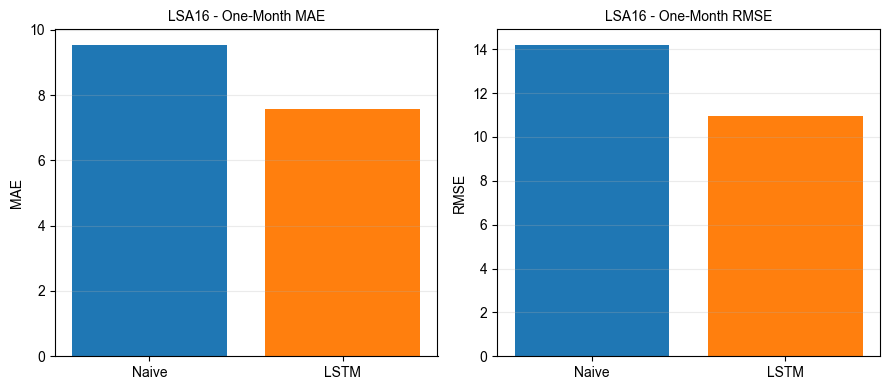

In [5]:
import matplotlib.pyplot as plt

# ============================================================
# THESIS FIGURE STYLE
# ============================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})
import pandas as pd

metrics_df = pd.DataFrame({
    "model": ["Naive", "LSTM"],
    "MAE": [overall_mae_naive, overall_mae_lstm],
    "RMSE": [overall_rmse_naive, overall_rmse_lstm]
})

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

axes[0].bar(metrics_df["model"], metrics_df["MAE"], color=["tab:blue", "tab:orange"])
axes[0].set_title(f"{LSA_NAME} - One-Month MAE")
axes[0].set_ylabel("MAE")
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar(metrics_df["model"], metrics_df["RMSE"], color=["tab:blue", "tab:orange"])
axes[1].set_title(f"{LSA_NAME} - One-Month RMSE")
axes[1].set_ylabel("RMSE")
axes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

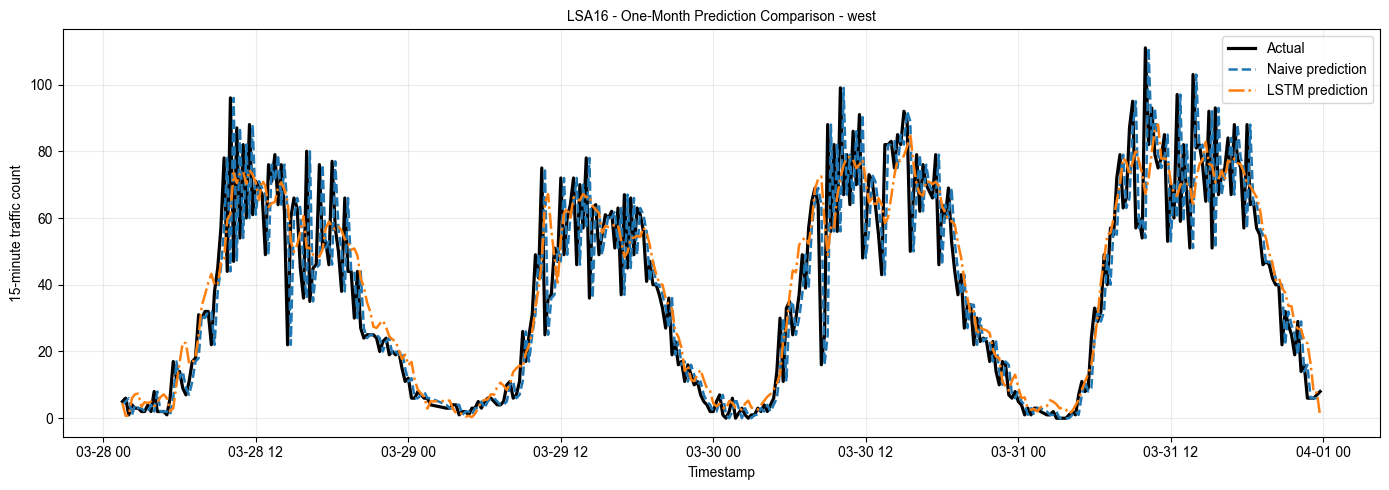

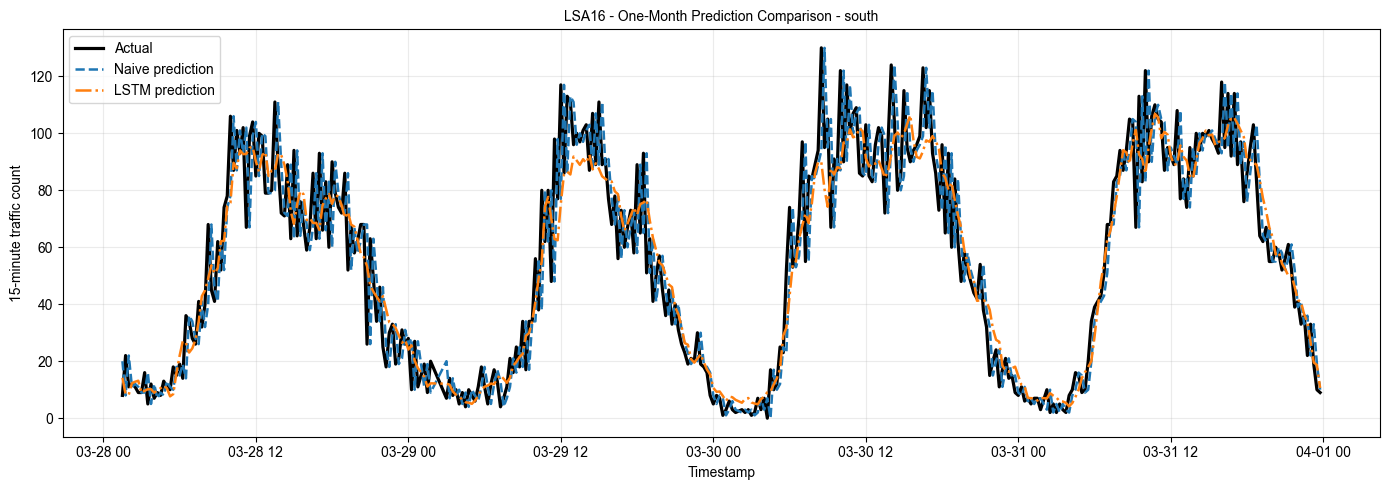

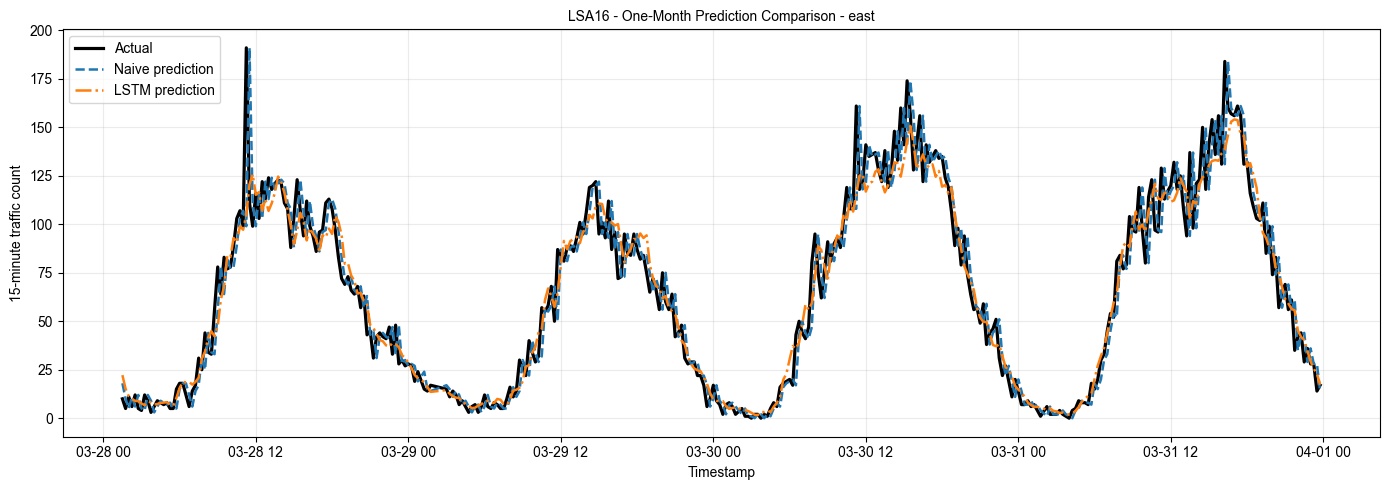

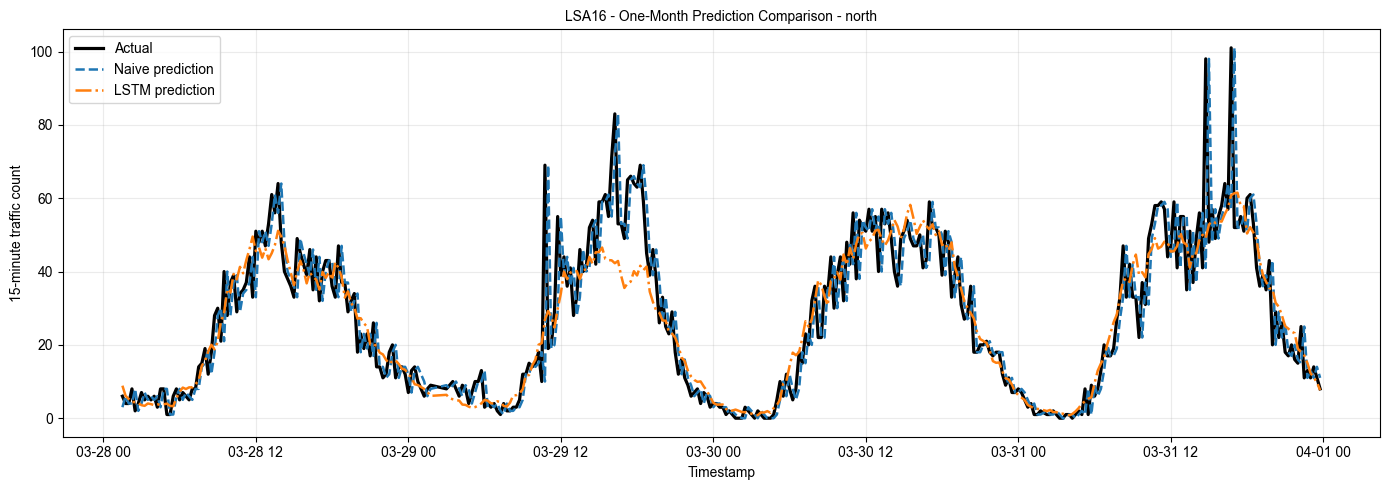

In [6]:
import matplotlib.pyplot as plt

# ============================================================
# THESIS FIGURE STYLE
# ============================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})
import pandas as pd

full_test_timestamps = test_df["timestamp_berlin"].reset_index(drop=True)

aligned_test_timestamps = full_test_timestamps.iloc[
    LOOKBACK + HORIZON - 1 : LOOKBACK + HORIZON - 1 + len(y_test_actual)
].reset_index(drop=True)

window_start = aligned_test_timestamps.min()
window_end = window_start + pd.Timedelta(days=4)

mask = (aligned_test_timestamps >= window_start) & (aligned_test_timestamps <= window_end)

for feature in count_cols:
    idx = count_cols.index(feature)

    plt.figure(figsize=(14, 5))

    plt.plot(
        aligned_test_timestamps[mask],
        y_test_actual[mask, idx],
        label="Actual",
        color="black",
        linewidth=2.3
    )

    plt.plot(
        aligned_test_timestamps[mask],
        y_pred_naive_actual[mask, idx],
        label="Naive prediction",
        color="tab:blue",
        linestyle="--",
        linewidth=1.8
    )

    plt.plot(
        aligned_test_timestamps[mask],
        y_pred_lstm_actual[mask, idx],
        label="LSTM prediction",
        color="tab:orange",
        linestyle="-.",
        linewidth=1.8
    )

    plt.title(f"{LSA_NAME} - One-Month Prediction Comparison - {feature.replace(LSA_NAME + '_', '').replace('_count', '')}")
    plt.xlabel("Timestamp")
    plt.ylabel("15-minute traffic count")
    plt.legend()
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

********
**For the 15-minute forecast horizon at LSA16, the one-month training experiment produced results comparable to, and slightly better than, the model trained with the longer historical dataset. The one-month LSTM achieved an MAE of 7.558 and an RMSE of 10.953, compared with 7.618 and 11.788 for the longer-data model. This indicates that for short-term forecasting, recent data may be particularly valuable because it reflects the current traffic regime more closely. However, the result should not be interpreted as showing that longer data are unnecessary in general, since longer datasets may still improve robustness under seasonal variation, unusual demand patterns, or changing traffic conditions.**
************